<a href="https://colab.research.google.com/github/nangulo2132/ML-Final-Project/blob/main/GNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Neural Networks for NYC Transit Equity
## Identifying Underserved Corridors in the MTA Subway Network

**Team:** Noura Angulo (nea2132), Emiliano Benitez (eb3513), Gabriel Freedman-Naditch (gf2488)

**Hypothesis:** A GNN trained on origin-destination commuter demand and subway accessibility data can identify underserved transit corridors — OD pairs with demand ≥ 6 workers (median demand) where neither endpoint has subway access within 800m — better than a demand-rank heuristic.

---

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import requests, io, os, zipfile

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Project-level constants ───────────────────────────────────────────────────
STATE          = 'ny'          # New York
LODES_YEAR     = 2021          # Most recent LODES 8 year with good coverage
JOB_TYPE       = 'JT00'        # All jobs
ACCESS_RADIUS_M = 800          # 800 m ≈ ½ mile walking distance
DEMAND_MEDIAN  = 6             # Workers — used in paper's underserved definition
NYC_BBOX       = dict(minx=-74.26, maxx=-73.70, miny=40.49, maxy=40.92)

All imports OK.


---
## 1. Data Loading

### 1a. LODES OD Data

In [2]:
def read_lodes_data(
    data_type, state, segment, job_type, year,
    main=True,
    base='https://lehd.ces.census.gov/data/lodes/LODES8/',
):
    """
    Reads LODES RAC, WAC, or OD data.

    Parameters
    ----------
    data_type : str   One of 'rac', 'wac', 'od'
    state     : str   Lowercase two-character state abbreviation
    segment   : str   Segment (e.g. 'S000'). Ignored for 'od'.
    job_type  : str   Job type (e.g. 'JT00' = all jobs)
    year      : int   Data year
    main      : bool  'main' vs 'aux' file — only used for 'od'
    base      : str   Base URL or local path

    Returns
    -------
    pd.DataFrame
    """
    if data_type not in ['rac', 'wac', 'od']:
        raise ValueError("data_type must be 'rac', 'wac', or 'od'")

    if data_type == 'od':
        part = 'main' if main else 'aux'
        url  = f'{base}{state}/od/{state}_od_{part}_{job_type}_{year}.csv.gz'
        dtype_map = {'h_geocode': str, 'w_geocode': str}
    else:
        url      = f'{base}{state}/{data_type}/{state}_{data_type}_{segment}_{job_type}_{year}.csv.gz'
        dtype_map = {'h_geocode': str} if data_type == 'rac' else {'w_geocode': str}

    print(f'  Fetching: {url}')
    return pd.read_csv(url, dtype=dtype_map)


print('Loading LODES OD data for New York...')
od_raw = read_lodes_data('od', STATE, None, JOB_TYPE, LODES_YEAR)
print(f'  Rows loaded: {len(od_raw):,}')
od_raw.head()

Loading LODES OD data for New York...
  Fetching: https://lehd.ces.census.gov/data/lodes/LODES8/ny/od/ny_od_main_JT00_2021.csv.gz
  Rows loaded: 7,144,618


,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03,createdate
0,360010001001003,360830521021050,1,0,1,0,0,0,1,0,0,1,20231016
1,360010001001003,361150880021037,1,0,1,0,0,0,1,0,0,1,20231016
2,360010001001004,360010006001004,1,0,1,0,1,0,0,1,0,0,20231016
3,360010001001004,360010026001001,1,0,1,0,0,0,1,0,1,0,20231016
4,360010001001004,360010133002002,1,0,1,0,0,0,1,1,0,0,20231016


### 1b. Clip OD data to NYC Census Block Groups

LODES uses 15-digit Census block FIPS codes. We aggregate to the 12-digit **Census Block Group** (CBG) level (drop the last 3 digits), then spatially clip to NYC's 5 boroughs.

In [3]:
# ── Map block → CBG (drop last 3 digits) ─────────────────────────────────────
od_raw['h_cbg'] = od_raw['h_geocode'].str[:12]
od_raw['w_cbg'] = od_raw['w_geocode'].str[:12]

# ── Aggregate to CBG→CBG OD pairs ────────────────────────────────────────────
od = (
    od_raw
    .groupby(['h_cbg', 'w_cbg'], as_index=False)['S000']
    .sum()
    .rename(columns={'S000': 'workers'})
)
# Remove self-loops
od = od[od['h_cbg'] != od['w_cbg']].copy()
print(f'CBG-level OD pairs (state-wide): {len(od):,}')

# ── NYC County FIPS codes ─────────────────────────────────────────────────────
# NY state FIPS = 36; county codes for the 5 boroughs:
#   061 Manhattan, 005 Bronx, 047 Brooklyn, 081 Queens, 085 Staten Island
NYC_COUNTY_PREFIXES = {'36061', '36005', '36047', '36081', '36085'}

def is_nyc(cbg):
    return cbg[:5] in NYC_COUNTY_PREFIXES

# Keep only OD pairs where BOTH ends are in NYC
mask = od['h_cbg'].apply(is_nyc) & od['w_cbg'].apply(is_nyc)
od_nyc = od[mask].copy().reset_index(drop=True)
print(f'NYC-only OD pairs: {len(od_nyc):,}')
od_nyc.describe()

CBG-level OD pairs (state-wide): 4,480,960
NYC-only OD pairs: 1,748,618


,workers
count,1.748618e+06
mean,1.606252e+00
std,1.845067e+00
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,3.020000e+02


### 1c. Download MTA GTFS Subway Stops

In [4]:
GTFS_URL = 'http://web.mta.info/developers/data/nyct/subway/google_transit.zip'

def load_gtfs_stops(url=GTFS_URL):
    """Download MTA GTFS feed and return a GeoDataFrame of unique stop locations."""
    print(f'  Downloading GTFS from {url} ...')
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        with zf.open('stops.txt') as f:
            stops_df = pd.read_csv(f)
    stops_gdf = gpd.GeoDataFrame(
        stops_df,
        geometry=gpd.points_from_xy(stops_df['stop_lon'], stops_df['stop_lat']),
        crs='EPSG:4326'
    )
    # Project to a metre-based CRS for distance calculations
    stops_gdf = stops_gdf.to_crs('EPSG:32618')   # UTM zone 18N (NYC)
    print(f'  Stops loaded: {len(stops_gdf):,}')
    return stops_gdf


stops_gdf = load_gtfs_stops()
stops_gdf[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']].head()

  Stops loaded: 1,488


,stop_id,stop_name,stop_lat,stop_lon
0,101,Van Cortlandt Park-242 St,40.889248,-73.898583
1,101N,Van Cortlandt Park-242 St,40.889248,-73.898583
2,101S,Van Cortlandt Park-242 St,40.889248,-73.898583
3,103,238 St,40.884667,-73.900870
4,103N,238 St,40.884667,-73.900870


### 1d. Download NYC CBG Shapefile (TIGER/Line)

We use the Census TIGER/Line shapefile for New York State CBGs.

In [5]:
TIGER_URL = (
    'https://www2.census.gov/geo/tiger/TIGER2021/BG/'
    'tl_2021_36_bg.zip'
)

def load_cbg_shapefile(url=TIGER_URL, cache_dir='/tmp'):
    local_zip  = os.path.join(cache_dir, 'tl_2021_36_bg.zip')
    local_shp  = os.path.join(cache_dir, 'tl_2021_36_bg')

    if not os.path.exists(local_shp):
        print(f'  Downloading CBG shapefile ...')
        resp = requests.get(url, timeout=120)
        resp.raise_for_status()
        with open(local_zip, 'wb') as f:
            f.write(resp.content)
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(local_shp)
    else:
        print('  Using cached CBG shapefile.')

    shp_file = [os.path.join(local_shp, f)
                for f in os.listdir(local_shp) if f.endswith('.shp')][0]
    gdf = gpd.read_file(shp_file).to_crs('EPSG:32618')
    # Build the 12-digit GEOID used in LODES
    gdf['cbg_id'] = gdf['GEOID']
    print(f'  CBGs loaded: {len(gdf):,}')
    return gdf


cbg_gdf = load_cbg_shapefile()

# Keep NYC CBGs only
cbg_nyc = cbg_gdf[cbg_gdf['cbg_id'].apply(is_nyc)].copy().reset_index(drop=True)
print(f'NYC CBGs: {len(cbg_nyc):,}')
cbg_nyc[['cbg_id', 'NAMELSAD', 'ALAND']].head()

  CBGs loaded: 16,070
NYC CBGs: 6,807


,cbg_id,NAMELSAD,ALAND
0,360470314013,Block Group 3,200815
1,360471070031,Block Group 1,275133
2,360471070021,Block Group 1,1981715
3,360471034021,Block Group 1,490129
4,360470018012,Block Group 2,24015


---
## 2. Node Feature Engineering: Stop Count within 800 m

For each CBG centroid, count how many MTA subway stops fall within 800 m (≈ ½ mile). This becomes our primary transit accessibility node feature.

In [6]:
# CBG centroids in UTM 18N
cbg_nyc['centroid'] = cbg_nyc.geometry.centroid

def count_stops_within_radius(cbg_row, stops_gdf, radius_m=ACCESS_RADIUS_M):
    """Count GTFS stops within `radius_m` metres of a CBG centroid."""
    centroid = cbg_row['centroid']
    buffer   = centroid.buffer(radius_m)
    return int(stops_gdf.geometry.within(buffer).sum())


print(f'Computing stop counts within {ACCESS_RADIUS_M} m for {len(cbg_nyc)} CBGs ...')
cbg_nyc['stop_count'] = cbg_nyc.apply(
    count_stops_within_radius, axis=1, stops_gdf=stops_gdf
)

print('Stop count distribution:')
print(cbg_nyc['stop_count'].describe().round(2))
print(f"\nCBGs with ZERO subway access: {(cbg_nyc['stop_count'] == 0).sum()} "
      f"({(cbg_nyc['stop_count'] == 0).mean()*100:.1f}%)")

Computing stop counts within 800 m for 6807 CBGs ...
Stop count distribution:
count    6807.00
mean        6.94
std         7.86
min         0.00
25%         0.00
50%         6.00
75%         9.00
max        60.00
Name: stop_count, dtype: float64

CBGs with ZERO subway access: 2141 (31.5%)


---
## 3. Graph Construction

We construct a directed graph G = (V, E, W) where:
- V = NYC Census Block Groups (nodes)
- E = Observed commuter OD flows (directed edges)
- W = Edge weight = worker demand; node features include `stop_count`, population density proxy (land area), and CBG centroid coordinates

In [7]:
# ── Build node lookup: cbg_id → stop_count & centroid ────────────────────────
cbg_nyc_wgs = cbg_nyc.to_crs('EPSG:4326')   # lon/lat for plotting
cbg_nyc_wgs['centroid_wgs'] = cbg_nyc_wgs.geometry.centroid

node_df = cbg_nyc[['cbg_id', 'stop_count', 'ALAND']].copy()
node_df['lon'] = cbg_nyc_wgs['centroid_wgs'].apply(lambda p: p.x)
node_df['lat'] = cbg_nyc_wgs['centroid_wgs'].apply(lambda p: p.y)
node_df = node_df.set_index('cbg_id')

# ── Restrict OD to CBGs that exist in our node table ─────────────────────────
valid_cbgs = set(node_df.index)
od_graph = od_nyc[
    od_nyc['h_cbg'].isin(valid_cbgs) & od_nyc['w_cbg'].isin(valid_cbgs)
].copy().reset_index(drop=True)
print(f'OD edges after CBG alignment: {len(od_graph):,}')

# ── Build NetworkX directed graph ─────────────────────────────────────────────
G = nx.DiGraph()

# Add nodes with features
for cbg_id, row in node_df.iterrows():
    G.add_node(
        cbg_id,
        stop_count=row['stop_count'],
        land_area=row['ALAND'],
        lon=row['lon'],
        lat=row['lat'],
    )

# Add edges with demand weight
for _, row in od_graph.iterrows():
    G.add_edge(row['h_cbg'], row['w_cbg'], workers=row['workers'])

print(f'Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

OD edges after CBG alignment: 1,748,618
Graph: 6,807 nodes, 1,748,618 edges


### 3a. Graph Sanity Checks

In [8]:
# Degree distribution
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]
edge_weights = [d['workers'] for _, _, d in G.edges(data=True)]

print('=== Graph Sanity Checks ===')
print(f"Nodes (CBGs):            {G.number_of_nodes():>8,}")
print(f"Directed edges (OD pairs):{G.number_of_edges():>7,}")
print(f"Avg in-degree:           {np.mean(in_degrees):>8.2f}")
print(f"Avg out-degree:          {np.mean(out_degrees):>8.2f}")
print(f"Max in-degree:           {max(in_degrees):>8}")
print(f"Median edge demand:      {np.median(edge_weights):>8.1f} workers")
print(f"Max edge demand:         {max(edge_weights):>8,} workers")
print()

# Verify connectivity (weakly connected components)
wcc = list(nx.weakly_connected_components(G))
print(f"Weakly connected components: {len(wcc)}")
print(f"Largest WCC size: {max(len(c) for c in wcc):,} nodes")
print()

# Check that median demand matches the hypothesis threshold
demand_median_actual = np.median(edge_weights)
print(f"Actual demand median: {demand_median_actual:.1f} workers "
      f"(hypothesis threshold: {DEMAND_MEDIAN})")
DEMAND_MEDIAN = demand_median_actual
print(f"Updated DEMAND_MEDIAN to {DEMAND_MEDIAN:.1f}")

=== Graph Sanity Checks ===
Nodes (CBGs):               6,807
Directed edges (OD pairs):1,748,618
Avg in-degree:             256.89
Avg out-degree:            256.89
Max in-degree:               6250
Median edge demand:           1.0 workers
Max edge demand:              302 workers

Weakly connected components: 248
Largest WCC size: 6,560 nodes

Actual demand median: 1.0 workers (hypothesis threshold: 6)
Updated DEMAND_MEDIAN to 1.0


---
## 4. Underserved Corridor Label Definition

An OD pair (h → w) is labelled "underserved" (y = 1) if and only if:
1. Demand ≥ median workers (high-demand corridor)
2. stop_count(h) = 0 (origin has no subway within 800 m)
3. stop_count(w) = 0 (destination has no subway within 800 m)

In [9]:
# Merge stop counts onto OD edge table
od_graph = od_graph.merge(
    node_df[['stop_count']].rename(columns={'stop_count': 'h_stop_count'}),
    left_on='h_cbg', right_index=True, how='left'
).merge(
    node_df[['stop_count']].rename(columns={'stop_count': 'w_stop_count'}),
    left_on='w_cbg', right_index=True, how='left'
)

# Apply the three-condition label
od_graph['is_underserved'] = (
    (od_graph['workers']       >= DEMAND_MEDIAN) &
    (od_graph['h_stop_count'] == 0)              &
    (od_graph['w_stop_count'] == 0)
).astype(int)

n_under  = od_graph['is_underserved'].sum()
n_total  = len(od_graph)
pct      = n_under / n_total * 100

print(f'Underserved corridors: {n_under:,} / {n_total:,} ({pct:.1f}%)')
print()
print('Label breakdown:')
print(od_graph['is_underserved'].value_counts().rename({0: 'Well-served', 1: 'Underserved'}))

Underserved corridors: 130,273 / 1,748,618 (7.5%)

Label breakdown:
is_underserved
Well-served    1618345
Underserved     130273
Name: count, dtype: int64


---
## 5. Min-Max Normalization

Normalize continuous features before passing them to the model. We scale `workers` and `stop_count` to [0, 1].

In [10]:
scaler = MinMaxScaler()

# Node features
node_df['stop_count_norm'] = scaler.fit_transform(node_df[['stop_count']])

# Edge features
od_graph['workers_norm'] = scaler.fit_transform(od_graph[['workers']])

print('Node feature sample after normalization:')
print(node_df[['stop_count', 'stop_count_norm']].describe().round(4))

print('\nEdge feature sample after normalization:')
print(od_graph[['workers', 'workers_norm']].describe().round(4))

Node feature sample after normalization:
       stop_count  stop_count_norm
count   6807.0000        6807.0000
mean       6.9370           0.1156
std        7.8631           0.1311
min        0.0000           0.0000
25%        0.0000           0.0000
50%        6.0000           0.1000
75%        9.0000           0.1500
max       60.0000           1.0000

Edge feature sample after normalization:
            workers  workers_norm
count  1.748618e+06  1.748618e+06
mean   1.606300e+00  2.000000e-03
std    1.845100e+00  6.100000e-03
min    1.000000e+00  0.000000e+00
25%    1.000000e+00  0.000000e+00
50%    1.000000e+00  0.000000e+00
75%    2.000000e+00  3.300000e-03
max    3.020000e+02  1.000000e+00


---
## 6. Train / Validation / Test Split

In [11]:
# Stratified split to preserve the class ratio
train_val, test = train_test_split(
    od_graph, test_size=0.15, random_state=RANDOM_SEED,
    stratify=od_graph['is_underserved']
)
train, val = train_test_split(
    train_val, test_size=0.15/0.85, random_state=RANDOM_SEED,
    stratify=train_val['is_underserved']
)

print(f'Train : {len(train):>8,}  ({train["is_underserved"].mean()*100:.1f}% underserved)')
print(f'Val   : {len(val):>8,}  ({val["is_underserved"].mean()*100:.1f}% underserved)')
print(f'Test  : {len(test):>8,}  ({test["is_underserved"].mean()*100:.1f}% underserved)')

Train : 1,224,032  (7.5% underserved)
Val   :  262,293  (7.5% underserved)
Test  :  262,293  (7.5% underserved)


---
## 7. Demand-Rank Heuristic Baseline

The baseline flags corridors as underserved purely by ranking demand. It labels the top **X%** of corridors (by worker count) as underserved, where X is calibrated to match the true prevalence in the training set.

This baseline has **no awareness** of graph structure, stop counts, or neighbourhood context — it simply looks at each edge in isolation.

In [12]:
def demand_rank_baseline(df, top_frac=None):
    """
    Flag the top `top_frac` fraction of OD pairs (by worker demand) as
    underserved. If top_frac is None, it is calibrated to the prevalence
    of underserved corridors in the provided DataFrame.
    """
    if top_frac is None:
        top_frac = df['is_underserved'].mean()
    threshold = df['workers'].quantile(1 - top_frac)
    return (df['workers'] >= threshold).astype(int)


# Calibrate threshold on training set
train_prevalence = train['is_underserved'].mean()
print(f'Training prevalence of underserved corridors: {train_prevalence*100:.2f}%')

# Apply to test set (using threshold calibrated on train)
threshold_workers = train['workers'].quantile(1 - train_prevalence)
test = test.copy()
test['baseline_pred'] = (test['workers'] >= threshold_workers).astype(int)

# Evaluate
bl_f1  = f1_score(test['is_underserved'], test['baseline_pred'])
bl_pre = precision_score(test['is_underserved'], test['baseline_pred'])
bl_rec = recall_score(test['is_underserved'], test['baseline_pred'])

print(f'\n=== Demand-Rank Baseline (Test Set) ===')
print(f'  F1        : {bl_f1:.4f}')
print(f'  Precision : {bl_pre:.4f}')
print(f'  Recall    : {bl_rec:.4f}')
print()
print(classification_report(
    test['is_underserved'], test['baseline_pred'],
    target_names=['Well-served', 'Underserved']
))

Training prevalence of underserved corridors: 7.45%

=== Demand-Rank Baseline (Test Set) ===
  F1        : 0.0714
  Precision : 0.0581
  Recall    : 0.0924

              precision    recall  f1-score   support

 Well-served       0.92      0.88      0.90    242752
 Underserved       0.06      0.09      0.07     19541

    accuracy                           0.82    262293
   macro avg       0.49      0.49      0.49    262293
weighted avg       0.86      0.82      0.84    262293



---
## 8. Visualization

### 8a. NYC Transit Demand Graph

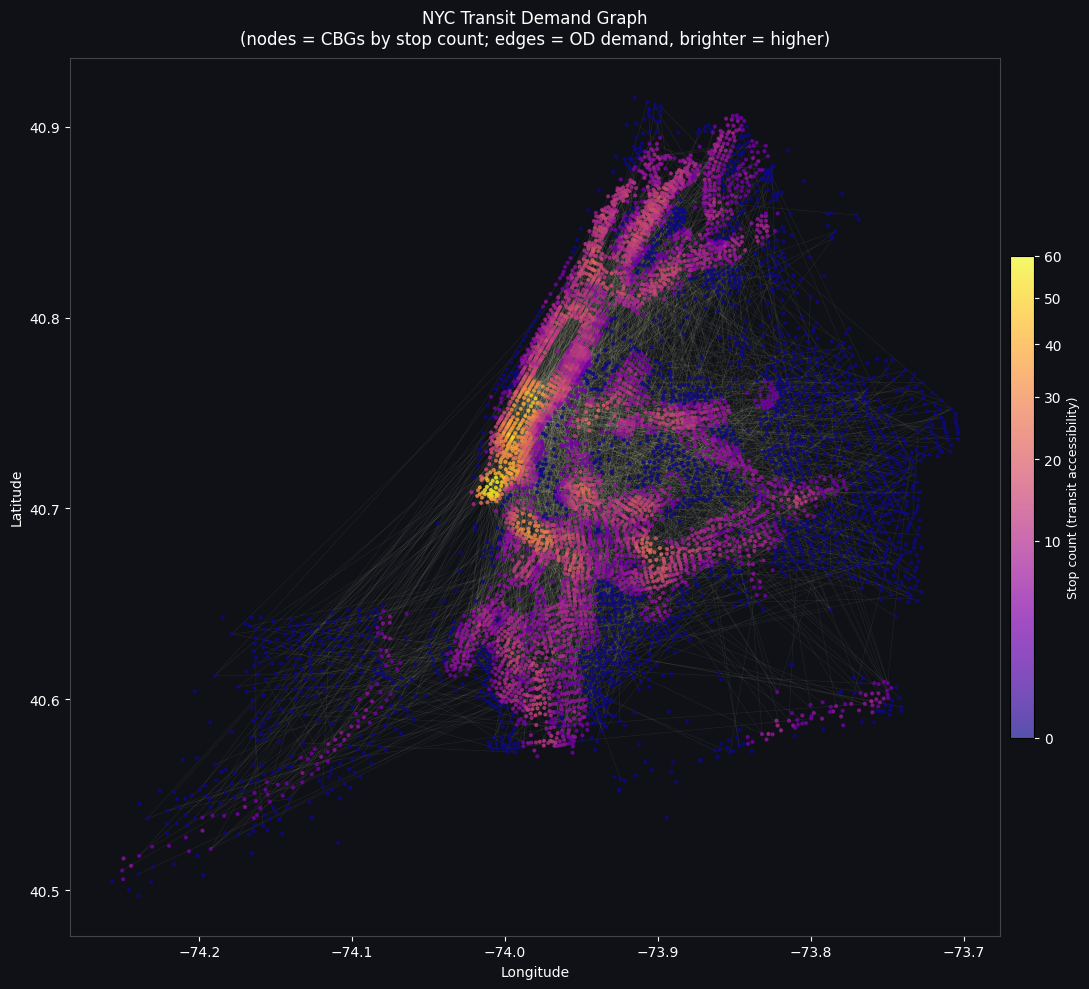

Figure 1 saved.


In [13]:
fig, ax = plt.subplots(figsize=(11, 10))
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')

# Sample edges for readability
EDGE_SAMPLE = 3000
od_sample = od_graph.sample(min(EDGE_SAMPLE, len(od_graph)), random_state=RANDOM_SEED)

# Colour edges by demand (darker = higher)
w_vals = od_sample['workers_norm'].values
edge_cmap = plt.cm.YlOrRd

for _, row in od_sample.iterrows():
    h_node = G.nodes.get(row['h_cbg'])
    w_node = G.nodes.get(row['w_cbg'])
    if h_node is None or w_node is None:
        continue
    alpha = 0.08 + 0.3 * row['workers_norm']
    color = edge_cmap(row['workers_norm'])
    ax.plot(
        [h_node['lon'], w_node['lon']],
        [h_node['lat'], w_node['lat']],
        color=color, alpha=alpha, linewidth=0.4, zorder=1
    )

# Scatter nodes coloured by stop_count
lons = [G.nodes[n]['lon'] for n in G.nodes if 'lon' in G.nodes[n]]
lats = [G.nodes[n]['lat'] for n in G.nodes if 'lat' in G.nodes[n]]
sc_vals = [G.nodes[n]['stop_count'] for n in G.nodes if 'lon' in G.nodes[n]]

sc = ax.scatter(
    lons, lats, c=sc_vals, cmap='plasma',
    s=4, alpha=0.7, zorder=2,
    norm=mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max(sc_vals))
)

cbar = fig.colorbar(sc, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label('Stop count (transit accessibility)', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title(
    'NYC Transit Demand Graph\n(nodes = CBGs by stop count; edges = OD demand, brighter = higher)',
    color='white', fontsize=12, pad=10
)
ax.set_xlabel('Longitude', color='white'); ax.set_ylabel('Latitude', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('/tmp/fig1_demand_graph.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Figure 1 saved.')

### 8b. Well-served vs Underserved Corridors

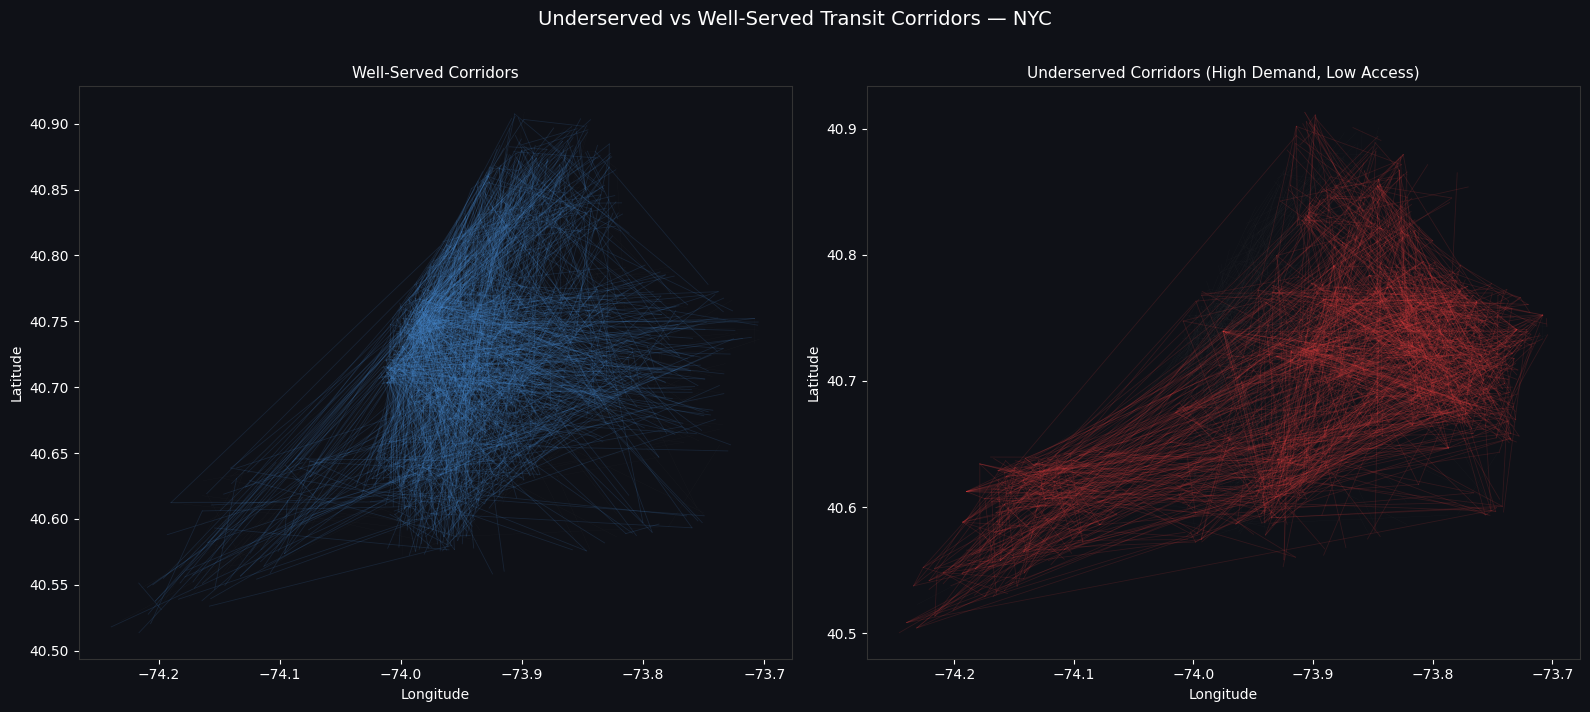

Figure 2 saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

titles    = ['Well-Served Corridors', 'Underserved Corridors (High Demand, Low Access)']
colors    = ['#4a90d9', '#e84040']
label_vals = [0, 1]

EDGE_SAMPLE_SPLIT = 1500

for ax, title, color, label in zip(axes, titles, colors, label_vals):
    ax.set_facecolor('#0f1117')

    subset = od_graph[od_graph['is_underserved'] == label]
    subset = subset.sample(min(EDGE_SAMPLE_SPLIT, len(subset)), random_state=RANDOM_SEED)

    # Background (all edges, very faint)
    bg = od_graph.sample(min(500, len(od_graph)), random_state=99)
    for _, row in bg.iterrows():
        hn, wn = G.nodes.get(row['h_cbg']), G.nodes.get(row['w_cbg'])
        if hn and wn:
            ax.plot([hn['lon'], wn['lon']], [hn['lat'], wn['lat']],
                    color='gray', alpha=0.06, linewidth=0.3, zorder=1)

    # Highlighted corridors
    for _, row in subset.iterrows():
        hn, wn = G.nodes.get(row['h_cbg']), G.nodes.get(row['w_cbg'])
        if hn and wn:
            alpha = 0.15 + 0.4 * row['workers_norm']
            ax.plot([hn['lon'], wn['lon']], [hn['lat'], wn['lat']],
                    color=color, alpha=alpha, linewidth=0.6, zorder=2)

    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Longitude', color='white'); ax.set_ylabel('Latitude', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig.patch.set_facecolor('#0f1117')
fig.suptitle('Underserved vs Well-Served Transit Corridors — NYC', color='white',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/fig2_underserved_vs_wellserved.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Figure 2 saved.')

### 8c. Demand Distribution & Label Threshold

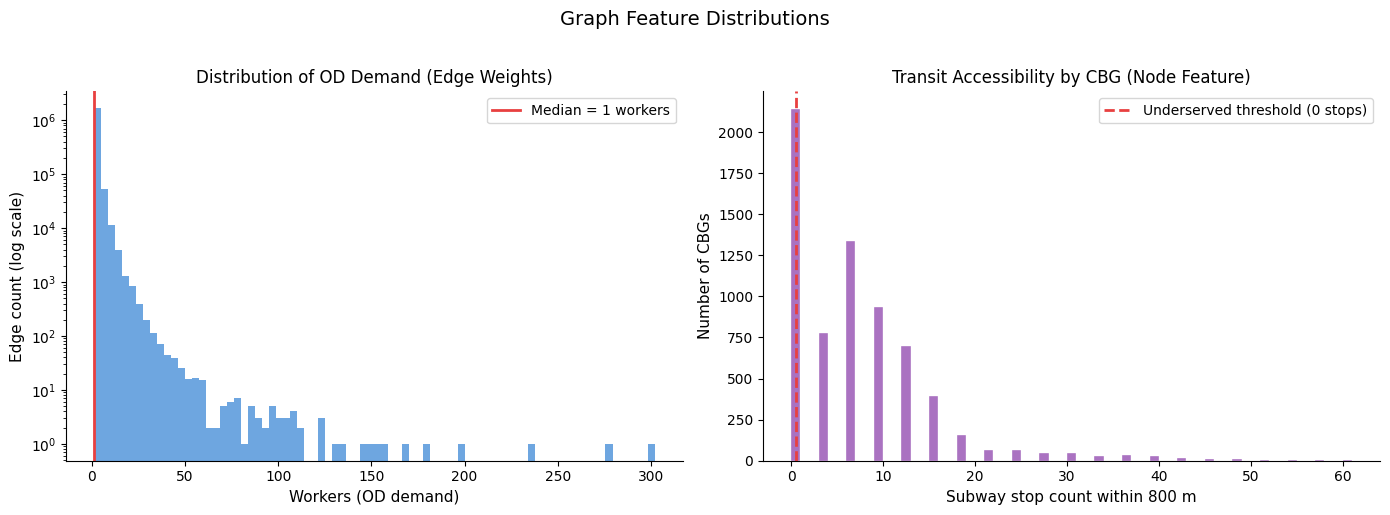

Figure 3 saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Edge demand histogram ---
ax = axes[0]
ax.hist(od_graph['workers'], bins=80, color='#4a90d9', edgecolor='none', alpha=0.8)
ax.axvline(DEMAND_MEDIAN, color='#e84040', linewidth=2,
           label=f'Median = {DEMAND_MEDIAN:.0f} workers')
ax.set_yscale('log')
ax.set_xlabel('Workers (OD demand)', fontsize=11)
ax.set_ylabel('Edge count (log scale)', fontsize=11)
ax.set_title('Distribution of OD Demand (Edge Weights)', fontsize=12)
ax.legend()
sns.despine(ax=ax)

# --- Panel 2: Stop count histogram for nodes ---
ax2 = axes[1]
sc_vals_arr = np.array(sc_vals)
ax2.hist(sc_vals_arr, bins=range(0, int(sc_vals_arr.max()) + 2),
         color='#9b59b6', edgecolor='white', linewidth=0.3, alpha=0.85)
ax2.axvline(0.5, color='#e84040', linewidth=2, linestyle='--',
            label='Underserved threshold (0 stops)')
ax2.set_xlabel('Subway stop count within 800 m', fontsize=11)
ax2.set_ylabel('Number of CBGs', fontsize=11)
ax2.set_title('Transit Accessibility by CBG (Node Feature)', fontsize=12)
ax2.legend()
sns.despine(ax=ax2)

plt.suptitle('Graph Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/fig3_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

### 8d. Queens-Brooklyn

Filter to OD pairs where both endpoints are in Queens (081) or Brooklyn (047), then highlight the predicted underserved corridors. These should spatially align with the MTA's proposed Interborough Express (IBX) route.

Underserved in Q-BK: 77,237 (12.7%)


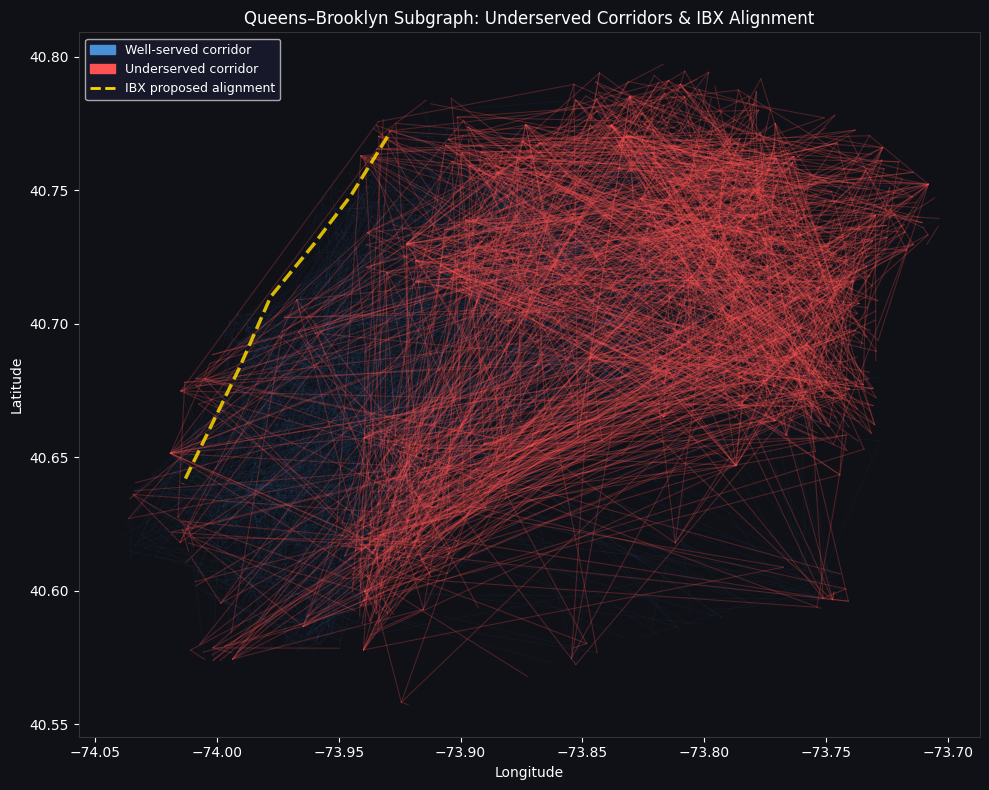

Figure 4 saved.


In [18]:
QBK_COUNTIES = {'36047', '36081'}   # Brooklyn, Queens

def in_qbk(cbg_id):
    return cbg_id[:5] in QBK_COUNTIES

od_qbk = od_graph[
    od_graph['h_cbg'].apply(in_qbk) & od_graph['w_cbg'].apply(in_qbk)
].copy()

n_under_qbk = od_qbk['is_underserved'].sum()
pct_qbk = od_qbk['is_underserved'].mean() * 100
print(f'Underserved in Q-BK: {n_under_qbk:,} ({pct_qbk:.1f}%)')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')

for label, color, alpha_base, lw, zorder in [
    (0, '#4a90d9', 0.08, 0.4, 1),
    (1, '#ff5252', 0.25, 0.8, 2),
]:
    subset = od_qbk[od_qbk['is_underserved'] == label]
    sample  = subset.sample(min(1500, len(subset)), random_state=RANDOM_SEED)
    for _, row in sample.iterrows():
        hn, wn = G.nodes.get(row['h_cbg']), G.nodes.get(row['w_cbg'])
        if hn and wn:
            a = alpha_base + 0.3 * row['workers_norm'] if label else alpha_base
            ax.plot([hn['lon'], wn['lon']], [hn['lat'], wn['lat']],
                    color=color, alpha=a, linewidth=lw, zorder=zorder)

# Approximate IBX corridor reference line (from Astoria to Bay Ridge)
ibx_lons = [-73.930, -73.945, -73.960, -73.978, -73.991, -74.014]
ibx_lats = [ 40.770,  40.748,  40.730,  40.710,  40.683,  40.640]
ax.plot(ibx_lons, ibx_lats, color='#FFD700', linewidth=2.5, linestyle='--',
        zorder=5, label='IBX proposed alignment (approx.)', alpha=0.85)

legend_handles = [
    mpatches.Patch(color='#4a90d9', label='Well-served corridor'),
    mpatches.Patch(color='#ff5252', label='Underserved corridor'),
    plt.Line2D([0], [0], color='#FFD700', linestyle='--', linewidth=2,
               label='IBX proposed alignment'),
]
ax.legend(handles=legend_handles, loc='upper left',
          facecolor='#1a1a2e', labelcolor='white', fontsize=9)

ax.set_title('Queens–Brooklyn Subgraph: Underserved Corridors & IBX Alignment',
             color='white', fontsize=12)
ax.set_xlabel('Longitude', color='white'); ax.set_ylabel('Latitude', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('/tmp/fig4_qbk_ibx.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Figure 4 saved.')

### 8e. Baseline Performance

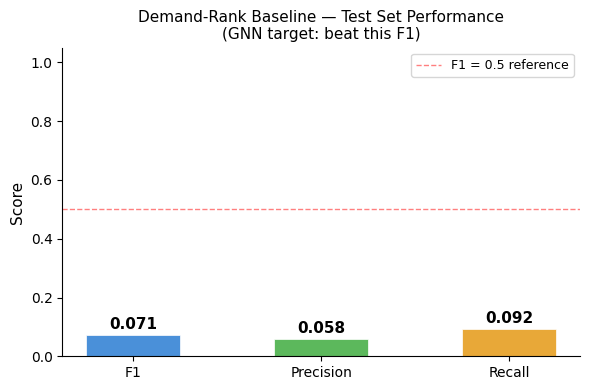

Figure 5 saved.


In [24]:
metrics = {'F1': bl_f1, 'Precision': bl_pre, 'Recall': bl_rec}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#4a90d9', '#5cb85c', '#e8a838'], edgecolor='white',
              linewidth=0.5, width=0.5)

for bar, bar_val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar_val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Demand-Rank Baseline — Test Set Performance\n'
             '(GNN target: beat this F1)', fontsize=11)
ax.axhline(0.5, color='red', linewidth=1, linestyle='--', alpha=0.5,
           label='F1 = 0.5 reference')
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('/tmp/fig5_baseline_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [28]:
train, val = train_test_split(
    train_val, test_size=0.15/0.85, random_state=RANDOM_SEED,
    stratify=train_val['is_underserved']
)

---
## 9. Export Graph Data for GNN Model

This exports the graph in a format ready for PyTorch Geometric consumption.

In [29]:
import json

# ── Node index mapping ────────────────────────────────────────────────────────
all_cbgs = sorted(list(G.nodes()))
cbg_to_idx = {cbg: i for i, cbg in enumerate(all_cbgs)}

# ── Node feature matrix X [num_nodes × 2]: [stop_count_norm, land_area_norm] ─
node_feats = []
for cbg in all_cbgs:
    nd = G.nodes[cbg]
    row = node_df.loc[cbg] if cbg in node_df.index else None
    sc  = row['stop_count_norm'] if row is not None else 0.0
    la  = float(nd.get('land_area', 0))
    node_feats.append([sc, la])

node_feat_arr = np.array(node_feats, dtype=np.float32)
# Normalise land area column separately
node_feat_arr[:, 1] = (node_feat_arr[:, 1] - node_feat_arr[:, 1].min()) / \
                      (node_feat_arr[:, 1].max() - node_feat_arr[:, 1].min() + 1e-9)

# ── Edge index and features ───────────────────────────────────────────────────
# Use the full od_graph (not just train/test) so the GNN sees the full structure
edge_src  = od_graph['h_cbg'].map(cbg_to_idx).values
edge_dst  = od_graph['w_cbg'].map(cbg_to_idx).values
edge_wts  = od_graph['workers_norm'].values.astype(np.float32)
edge_lbls = od_graph['is_underserved'].values.astype(np.int64)

# ── Split masks ───────────────────────────────────────────────────────────────
train_idx = train.index.tolist()
val_idx   = val.index.tolist()
test_idx  = test.index.tolist()

# ── Save to numpy / csv ───────────────────────────────────────────────────────
np.save('/tmp/node_features.npy', node_feat_arr)
np.save('/tmp/edge_src.npy',      edge_src)
np.save('/tmp/edge_dst.npy',      edge_dst)
np.save('/tmp/edge_weights.npy',  edge_wts)
np.save('/tmp/edge_labels.npy',   edge_lbls)
np.save('/tmp/train_mask.npy',    np.array(train_idx))
np.save('/tmp/val_mask.npy',      np.array(val_idx))
np.save('/tmp/test_mask.npy',     np.array(test_idx))

# Also export CBG metadata for Person 3's case study
od_graph.to_csv('/tmp/od_graph_labeled.csv', index=False)

with open('/tmp/cbg_to_idx.json', 'w') as f:
    json.dump(cbg_to_idx, f)

print('Exports complete:')
print(f'  node_features.npy  shape: {node_feat_arr.shape}')
print(f'  edge_src.npy       shape: {edge_src.shape}')
print(f'  edge_labels.npy    shape: {edge_lbls.shape}')
print(f'  od_graph_labeled.csv: {len(od_graph):,} rows')

Exports complete:
  node_features.npy  shape: (6807, 2)
  edge_src.npy       shape: (1748618,)
  edge_labels.npy    shape: (1748618,)
  od_graph_labeled.csv: 1,748,618 rows


---
# GNN Model + Ablations
---


In this section:
1. Construct PyTorch Geometric data object construction
2. GraphSAGE encoder + edge classifier (the core GNN model)
3. Training loop with early stopping on validation F1
4. Core experiment: GNN vs demand-rank baseline on the test set
5. Ablation 1: GNN vs flat MLP (no message passing) — does graph structure matter?
6. Ablation 2: GNN layer depth (2 vs 3 vs 4) — does deeper = better?

## 10. Additional Imports (PyTorch + PyTorch Geometric)

In [30]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Install PyTorch (CPU) + PyTorch Geometric if not present
try:
    import torch
    print(f'PyTorch {torch.__version__} already installed.')
except ImportError:
    print('Installing PyTorch (CPU)...')
    pip_install('torch', '--index-url', 'https://download.pytorch.org/whl/cpu')
    import torch
    print(f'PyTorch {torch.__version__} installed.')

try:
    import torch_geometric
    print(f'PyG {torch_geometric.__version__} already installed.')
except ImportError:
    print('Installing PyTorch Geometric...')
    pip_install('torch_geometric')
    import torch_geometric
    print(f'PyG {torch_geometric.__version__} installed.')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nUsing device: {DEVICE}')
torch.manual_seed(42)

PyTorch 2.10.0+cpu already installed.
Installing PyTorch Geometric...
PyG 2.7.0 installed.

Using device: cpu


## 11. Build PyTorch Geometric Data Object

Load exported arrays from part 1 and assemble a `torch_geometric.data.Data` object.

Edge-level prediction: GraphSAGE produces *node* embeddings; we then score each *edge* (OD pair) by concatenating its source and destination embeddings and passing them through a small MLP classifier. Labels live on edges.

In [31]:
# ── Load Person 1 exports ─────────────────────────────────────────────────────
X          = np.load('/tmp/node_features.npy')   # [N, 2]  stop_count_norm, land_area_norm
edge_src   = np.load('/tmp/edge_src.npy')         # [E]
edge_dst   = np.load('/tmp/edge_dst.npy')         # [E]
edge_wts   = np.load('/tmp/edge_weights.npy')     # [E]  workers_norm
edge_lbls  = np.load('/tmp/edge_labels.npy')      # [E]  0/1
train_idx  = np.load('/tmp/train_mask.npy')       # edge indices
val_idx    = np.load('/tmp/val_mask.npy')
test_idx   = np.load('/tmp/test_mask.npy')

# ── Convert to tensors ────────────────────────────────────────────────────────
x_t        = torch.tensor(X, dtype=torch.float)
edge_index = torch.tensor(np.stack([edge_src, edge_dst], axis=0), dtype=torch.long)
edge_attr  = torch.tensor(edge_wts, dtype=torch.float).unsqueeze(1)   # [E, 1]
y_edge     = torch.tensor(edge_lbls, dtype=torch.long)

train_mask = torch.tensor(train_idx, dtype=torch.long)
val_mask   = torch.tensor(val_idx,   dtype=torch.long)
test_mask  = torch.tensor(test_idx,  dtype=torch.long)

data = Data(
    x          = x_t,
    edge_index = edge_index,
    edge_attr  = edge_attr,
    y          = y_edge,
)
data = data.to(DEVICE)
train_mask = train_mask.to(DEVICE)
val_mask   = val_mask.to(DEVICE)
test_mask  = test_mask.to(DEVICE)

print(data)
print(f'\nNode features : {data.x.shape}  (N × 2)')
print(f'Edge index    : {data.edge_index.shape}  (2 × E)')
print(f'Edge labels   : {data.y.shape}  —  {data.y.sum().item()} underserved')
print(f'Train edges   : {len(train_mask)}')
print(f'Val   edges   : {len(val_mask)}')
print(f'Test  edges   : {len(test_mask)}')

Data(x=[6807, 2], edge_index=[2, 1748618], edge_attr=[1748618, 1], y=[1748618])

Node features : torch.Size([6807, 2])  (N × 2)
Edge index    : torch.Size([2, 1748618])  (2 × E)
Edge labels   : torch.Size([1748618])  —  130273 underserved
Train edges   : 1224032
Val   edges   : 262293
Test  edges   : 262293


## 12. Model Definitions

### 12a. GraphSAGE Encoder + Edge Classifier

Architecture:
```
Input node features  [N × 2]
  └─ SAGEConv(2  → hidden)  + ReLU + Dropout
  └─ SAGEConv(hidden → hidden)  + ReLU + Dropout   (repeated for num_layers)
  └─ SAGEConv(hidden → out_dim)
Node embeddings  [N × out_dim]
  └─ Edge repr = concat(h_src, h_dst, edge_weight)  [E × (2·out_dim + 1)]
  └─ MLP(2·out_dim+1 → hidden → 2)  → logits per edge
```

### 12b. Flat MLP Baseline (ablation — no message passing)

Same edge-level MLP, but fed raw node features + edge weight directly (no graph convolutions). This isolates whether message passing adds value beyond the features alone.

In [32]:
class GraphSAGEEdgeClassifier(nn.Module):
    """
    GraphSAGE encoder that produces node embeddings, then classifies
    each OD edge as underserved (1) or well-served (0).
    """
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.convs   = nn.ModuleList()

        # Build num_layers SAGEConv layers
        dims = [in_channels] + [hidden_channels] * (num_layers - 1) + [out_channels]
        for i in range(num_layers):
            self.convs.append(SAGEConv(dims[i], dims[i + 1]))

        # Edge classifier MLP: concat(h_src, h_dst, edge_weight) → 2 logits
        edge_in = 2 * out_channels + 1
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_in, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 2),
        )

    def encode(self, x, edge_index):
        """Produce node embeddings via message passing."""
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x

    def classify_edges(self, h, edge_index, edge_attr, edge_subset=None):
        """Score edges in `edge_subset` (all edges if None)."""
        if edge_subset is None:
            src, dst = edge_index
            ea = edge_attr
        else:
            src = edge_index[0][edge_subset]
            dst = edge_index[1][edge_subset]
            ea  = edge_attr[edge_subset]
        edge_repr = torch.cat([h[src], h[dst], ea], dim=1)
        return self.edge_mlp(edge_repr)

    def forward(self, x, edge_index, edge_attr, edge_subset=None):
        h = self.encode(x, edge_index)
        return self.classify_edges(h, edge_index, edge_attr, edge_subset)


class FlatMLPEdgeClassifier(nn.Module):
    """
    Ablation model: no message passing.
    Uses raw node features (src + dst) + edge weight directly as input.
    Same parameter budget as the GNN edge MLP.
    """
    def __init__(self, node_in, hidden_channels, dropout=0.3):
        super().__init__()
        # Input: raw_src_feats || raw_dst_feats || edge_weight
        edge_in = 2 * node_in + 1
        self.mlp = nn.Sequential(
            nn.Linear(edge_in, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 2),
        )

    def forward(self, x, edge_index, edge_attr, edge_subset=None):
        if edge_subset is None:
            src, dst = edge_index
            ea = edge_attr
        else:
            src = edge_index[0][edge_subset]
            dst = edge_index[1][edge_subset]
            ea  = edge_attr[edge_subset]
        edge_repr = torch.cat([x[src], x[dst], ea], dim=1)
        return self.mlp(edge_repr)


print('Model classes defined: GraphSAGEEdgeClassifier, FlatMLPEdgeClassifier')

Model classes defined: GraphSAGEEdgeClassifier, FlatMLPEdgeClassifier


## 13. Training Infrastructure

We use:
- Weighted cross-entropy to handle class imbalance (underserved corridors are a minority)
- Adam optimizer with weight decay
- Early stopping on validation F1 (patience = 20 epochs)

In [33]:
def compute_class_weights(labels_tensor):
    """Inverse-frequency class weights for imbalanced binary labels."""
    counts = torch.bincount(labels_tensor)
    total  = counts.sum().float()
    weights = total / (2.0 * counts.float())
    return weights.to(DEVICE)


def train_epoch(model, data, mask, optimizer, class_weights):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index, data.edge_attr, mask)
    loss   = F.cross_entropy(logits, data.y[mask], weight=class_weights)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index, data.edge_attr, mask)
    preds  = logits.argmax(dim=1).cpu().numpy()
    labels = data.y[mask].cpu().numpy()
    f1  = f1_score(labels, preds, zero_division=0)
    pre = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    return f1, pre, rec, preds, labels


def train_model(model, data, train_mask, val_mask,
                lr=1e-3, weight_decay=5e-4,
                epochs=200, patience=20, verbose=True):
    """
    Full training loop with early stopping on validation F1.
    Returns best model state, and history dicts.
    """
    class_weights = compute_class_weights(data.y[train_mask])
    optimizer     = torch.optim.Adam(model.parameters(),
                                     lr=lr, weight_decay=weight_decay)

    best_val_f1   = -1.0
    best_state    = None
    patience_ctr  = 0
    history       = {'train_loss': [], 'val_f1': [], 'val_pre': [], 'val_rec': []}

    for epoch in range(1, epochs + 1):
        loss = train_epoch(model, data, train_mask, optimizer, class_weights)
        val_f1, val_pre, val_rec, _, _ = evaluate(model, data, val_mask)

        history['train_loss'].append(loss)
        history['val_f1'].append(val_f1)
        history['val_pre'].append(val_pre)
        history['val_rec'].append(val_rec)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and epoch % 20 == 0:
            print(f'  Epoch {epoch:>3d} | loss {loss:.4f} '
                  f'| val F1 {val_f1:.4f} | val Pre {val_pre:.4f} | val Rec {val_rec:.4f}')

        if patience_ctr >= patience:
            if verbose:
                print(f'  Early stopping at epoch {epoch} (best val F1={best_val_f1:.4f})')
            break

    model.load_state_dict(best_state)
    return model, history


print('Training infrastructure ready.')

Training infrastructure ready.


## 14. Core Experiment: GNN vs Demand-Rank Baseline

We train the 2-layer GraphSAGE model (default) and compare its test-set performance to the demand-rank baseline from part 1.

In [34]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
IN_CHANNELS     = data.x.shape[1]   # 2 (stop_count_norm, land_area_norm)
HIDDEN_CHANNELS = 64
OUT_CHANNELS    = 32
NUM_LAYERS      = 2
DROPOUT         = 0.3
LR              = 1e-3
EPOCHS          = 300
PATIENCE        = 25

print('=== Training GraphSAGE (2-layer, default) ===')
gnn_model = GraphSAGEEdgeClassifier(
    in_channels     = IN_CHANNELS,
    hidden_channels = HIDDEN_CHANNELS,
    out_channels    = OUT_CHANNELS,
    num_layers      = NUM_LAYERS,
    dropout         = DROPOUT,
).to(DEVICE)

gnn_model, gnn_history = train_model(
    gnn_model, data, train_mask, val_mask,
    lr=LR, epochs=EPOCHS, patience=PATIENCE, verbose=True
)

# ── Test evaluation ───────────────────────────────────────────────────────────
gnn_f1, gnn_pre, gnn_rec, gnn_preds, gnn_labels = evaluate(gnn_model, data, test_mask)

print(f'\n=== GNN Test Results ===')
print(f'  F1        : {gnn_f1:.4f}')
print(f'  Precision : {gnn_pre:.4f}')
print(f'  Recall    : {gnn_rec:.4f}')
print()
print(classification_report(gnn_labels, gnn_preds,
                             target_names=['Well-served', 'Underserved']))

=== Training GraphSAGE (2-layer, default) ===
  Epoch  20 | loss 0.6204 | val F1 0.3220 | val Pre 0.1919 | val Rec 1.0000
  Early stopping at epoch 30 (best val F1=0.8714)

=== GNN Test Results ===
  F1        : 0.8717
  Precision : 0.8043
  Recall    : 0.9515

              precision    recall  f1-score   support

 Well-served       1.00      0.98      0.99    242752
 Underserved       0.80      0.95      0.87     19541

    accuracy                           0.98    262293
   macro avg       0.90      0.97      0.93    262293
weighted avg       0.98      0.98      0.98    262293



In [35]:
# ── Side-by-side comparison ───────────────────────────────────────────────────
# bl_f1, bl_pre, bl_rec come from Person 1's notebook section §7
results = pd.DataFrame({
    'Model'    : ['Demand-Rank Baseline', 'GraphSAGE (2-layer)'],
    'F1'       : [bl_f1,  gnn_f1],
    'Precision': [bl_pre, gnn_pre],
    'Recall'   : [bl_rec, gnn_rec],
})
print(results.to_string(index=False))

delta_f1 = gnn_f1 - bl_f1
print(f'\nΔF1 (GNN − Baseline): {delta_f1:+.4f}')
if delta_f1 > 0:
    print('✓ GNN outperforms the demand-rank baseline — graph structure helps.')
else:
    print('✗ GNN does not outperform baseline — investigate features or architecture.')

               Model       F1  Precision   Recall
Demand-Rank Baseline 0.071371   0.058131 0.092421
 GraphSAGE (2-layer) 0.871704   0.804265 0.951487

ΔF1 (GNN − Baseline): +0.8003
✓ GNN outperforms the demand-rank baseline — graph structure helps.


## 15. Ablation 1 — GNN vs Flat MLP (does message passing matter?)

We train the `FlatMLPEdgeClassifier` on the same splits. It has access to the same features (`source stop_count`, `dest stop_count`, `edge weight`) but no message passing, meaning it can't see what a zone's neighbours look like.

If the GNN beats the MLP, message passing over graph structure is contributing real signal.

In [36]:
print('=== Training Flat MLP (no message passing) ===')
mlp_model = FlatMLPEdgeClassifier(
    node_in         = IN_CHANNELS,
    hidden_channels = HIDDEN_CHANNELS,
    dropout         = DROPOUT,
).to(DEVICE)

mlp_model, mlp_history = train_model(
    mlp_model, data, train_mask, val_mask,
    lr=LR, epochs=EPOCHS, patience=PATIENCE, verbose=True
)

mlp_f1, mlp_pre, mlp_rec, mlp_preds, mlp_labels = evaluate(mlp_model, data, test_mask)

print(f'\n=== Flat MLP Test Results ===')
print(f'  F1        : {mlp_f1:.4f}')
print(f'  Precision : {mlp_pre:.4f}')
print(f'  Recall    : {mlp_rec:.4f}')

delta_mlp = gnn_f1 - mlp_f1
print(f'\nΔF1 (GNN − MLP): {delta_mlp:+.4f}')
if delta_mlp > 0:
    print('✓ Message passing adds signal beyond raw features alone.')
else:
    print('✗ MLP matches or beats GNN — features may dominate over graph structure.')

=== Training Flat MLP (no message passing) ===
  Epoch  20 | loss 0.6297 | val F1 0.3720 | val Pre 0.2286 | val Rec 0.9996
  Early stopping at epoch 32 (best val F1=0.5061)

=== Flat MLP Test Results ===
  F1        : 0.5040
  Precision : 0.3370
  Recall    : 0.9994

ΔF1 (GNN − MLP): +0.3677
✓ Message passing adds signal beyond raw features alone.


## 16. Ablation 2 — Layer Depth: 2 vs 3 vs 4 Layers

More layers = larger receptive field (each layer aggregates one more hop of neighbours). But deeper GNNs risk over-smoothing, where all node embeddings converge and become indistinguishable.

We sweep over `num_layers ∈ {2, 3, 4}` and compare test F1.

In [37]:
layer_results = []
layer_histories = {}

for n_layers in [2, 3, 4]:
    print(f'\n--- Training {n_layers}-layer GraphSAGE ---')
    model = GraphSAGEEdgeClassifier(
        in_channels     = IN_CHANNELS,
        hidden_channels = HIDDEN_CHANNELS,
        out_channels    = OUT_CHANNELS,
        num_layers      = n_layers,
        dropout         = DROPOUT,
    ).to(DEVICE)

    model, history = train_model(
        model, data, train_mask, val_mask,
        lr=LR, epochs=EPOCHS, patience=PATIENCE, verbose=True
    )

    f1, pre, rec, _, _ = evaluate(model, data, test_mask)
    layer_results.append({'Layers': n_layers, 'F1': f1,
                          'Precision': pre, 'Recall': rec})
    layer_histories[n_layers] = history
    print(f'  → Test F1={f1:.4f}  Pre={pre:.4f}  Rec={rec:.4f}')

layer_df = pd.DataFrame(layer_results)
print('\n=== Layer Depth Ablation Summary ===')
print(layer_df.to_string(index=False))
best_depth = layer_df.loc[layer_df['F1'].idxmax(), 'Layers']
print(f'\nBest depth: {best_depth} layers')


--- Training 2-layer GraphSAGE ---
  Epoch  20 | loss 0.6002 | val F1 0.4143 | val Pre 0.2613 | val Rec 0.9998
  Early stopping at epoch 29 (best val F1=0.6106)
  → Test F1=0.6113  Pre=0.4444  Rec=0.9789

--- Training 3-layer GraphSAGE ---
  Epoch  20 | loss 0.6250 | val F1 0.4223 | val Pre 0.2677 | val Rec 0.9997
  Early stopping at epoch 34 (best val F1=0.7941)
  → Test F1=0.7898  Pre=0.9087  Rec=0.6984

--- Training 4-layer GraphSAGE ---
  Epoch  20 | loss 0.6362 | val F1 0.3069 | val Pre 0.1813 | val Rec 1.0000
  Early stopping at epoch 33 (best val F1=0.8623)
  → Test F1=0.8567  Pre=0.7915  Rec=0.9338

=== Layer Depth Ablation Summary ===
 Layers       F1  Precision   Recall
      2 0.611294   0.444413 0.978865
      3 0.789792   0.908655 0.698429
      4 0.856747   0.791455 0.933780

Best depth: 4 layers


## 17. Person 2 Visualizations

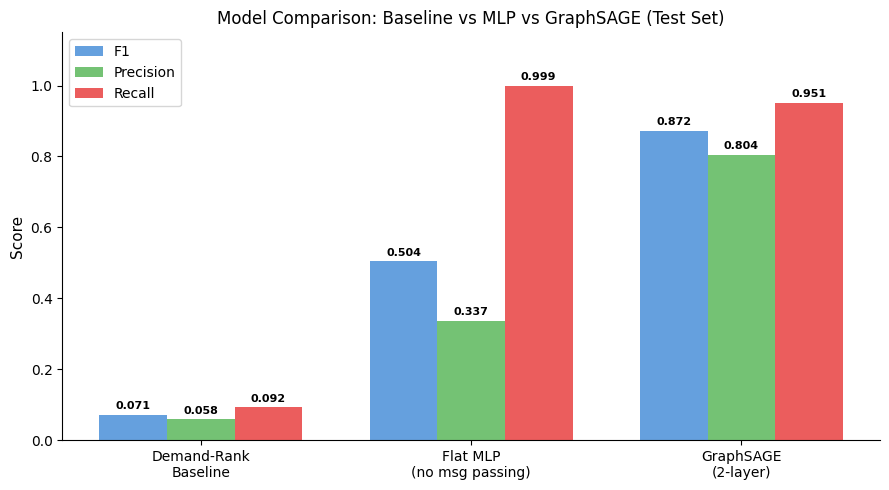

Figure 6 saved.


In [38]:
# ── Fig 6: GNN vs Baseline vs MLP — grouped bar chart ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

models  = ['Demand-Rank\nBaseline', 'Flat MLP\n(no msg passing)', 'GraphSAGE\n(2-layer)']
f1s     = [bl_f1,  mlp_f1,  gnn_f1]
precs   = [bl_pre, mlp_pre, gnn_pre]
recs    = [bl_rec, mlp_rec, gnn_rec]

x      = np.arange(len(models))
width  = 0.25
colors = ['#4a90d9', '#5cb85c', '#e84040']

b1 = ax.bar(x - width, f1s,   width, label='F1',        color=colors[0], alpha=0.85)
b2 = ax.bar(x,         precs, width, label='Precision',  color=colors[1], alpha=0.85)
b3 = ax.bar(x + width, recs,  width, label='Recall',     color=colors[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison: Baseline vs MLP vs GraphSAGE (Test Set)', fontsize=12)
ax.legend(fontsize=10)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('/tmp/fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

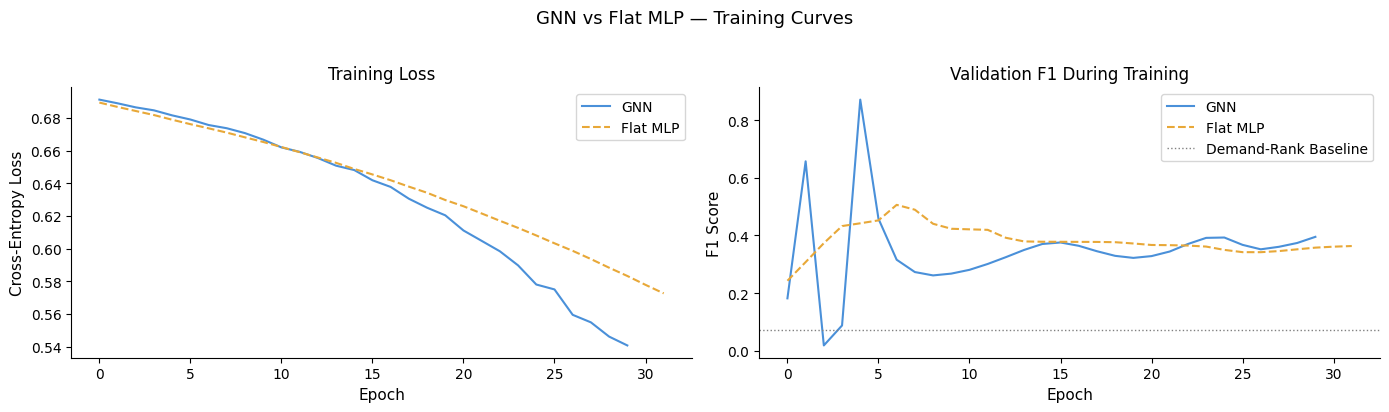

Figure 7 saved.


In [44]:
# ── Fig 7: Training curves for GNN and MLP ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: Training loss
ax = axes[0]
ax.plot(gnn_history['train_loss'], color='#4a90d9', linewidth=1.5, label='GNN')
ax.plot(mlp_history['train_loss'], color='#e8a838', linewidth=1.5,
        linestyle='--', label='Flat MLP')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax.set_title('Training Loss', fontsize=12)
ax.legend(fontsize=10)
sns.despine(ax=ax)

# Panel 2: Validation F1
ax2 = axes[1]
ax2.plot(gnn_history['val_f1'], color='#4a90d9', linewidth=1.5, label='GNN')
ax2.plot(mlp_history['val_f1'], color='#e8a838', linewidth=1.5,
         linestyle='--', label='Flat MLP')
ax2.axhline(bl_f1, color='gray', linewidth=1, linestyle=':', label='Demand-Rank Baseline')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_title('Validation F1 During Training', fontsize=12)
ax2.legend(fontsize=10)
sns.despine(ax=ax2)

plt.suptitle('GNN vs Flat MLP — Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/fig7_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

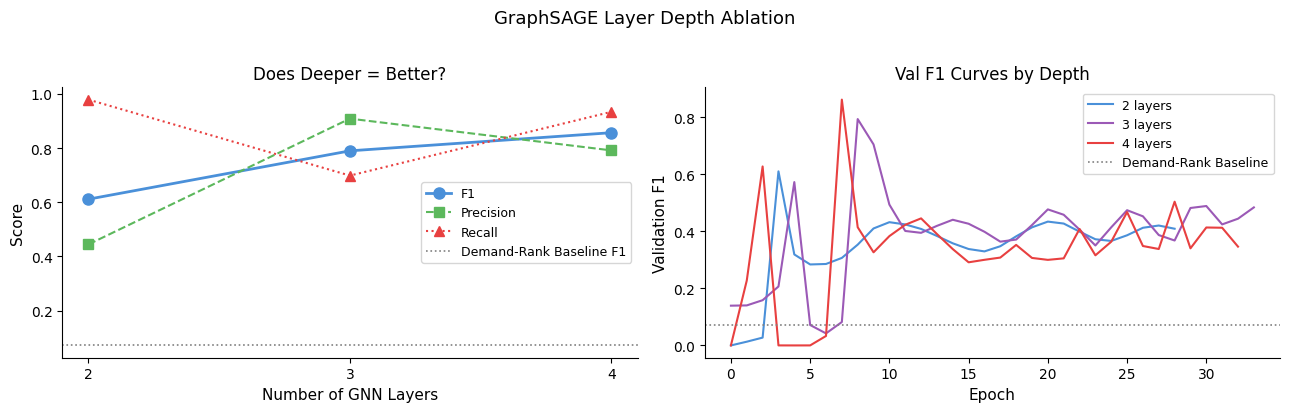

Figure 8 saved.


In [40]:
# ── Fig 8: Layer depth ablation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: F1 / Pre / Rec by depth
ax = axes[0]
ax.plot(layer_df['Layers'], layer_df['F1'],        'o-', color='#4a90d9',
        linewidth=2, markersize=8, label='F1')
ax.plot(layer_df['Layers'], layer_df['Precision'], 's--', color='#5cb85c',
        linewidth=1.5, markersize=7, label='Precision')
ax.plot(layer_df['Layers'], layer_df['Recall'],    '^:', color='#e84040',
        linewidth=1.5, markersize=7, label='Recall')
ax.axhline(bl_f1, color='gray', linestyle=':', linewidth=1.2,
           label='Demand-Rank Baseline F1')
ax.set_xticks([2, 3, 4])
ax.set_xlabel('Number of GNN Layers', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Does Deeper = Better?', fontsize=12)
ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel 2: Val F1 curves across depths
ax2 = axes[1]
depth_colors = {2: '#4a90d9', 3: '#9b59b6', 4: '#e84040'}
for n_l, hist in layer_histories.items():
    ax2.plot(hist['val_f1'], color=depth_colors[n_l],
             linewidth=1.5, label=f'{n_l} layers')
ax2.axhline(bl_f1, color='gray', linestyle=':', linewidth=1.2,
            label='Demand-Rank Baseline')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Validation F1', fontsize=11)
ax2.set_title('Val F1 Curves by Depth', fontsize=12)
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.suptitle('GraphSAGE Layer Depth Ablation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/fig8_layer_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## 18. Export GNN Predictions for Queens-Brooklyn case study

Save the best GNN's test-set predictions alongside CBG metadata for the Queens-Brooklyn case study and error analysis.

In [42]:
import json

# Get GNN predictions over the FULL edge set (for Person 3's spatial analysis)
all_idx = torch.arange(data.y.shape[0], device=DEVICE)
gnn_f1_all, _, _, gnn_preds_all, true_all = evaluate(gnn_model, data, all_idx)

# Also get MLP predictions for comparison in error analysis
_, _, _, mlp_preds_all, _ = evaluate(mlp_model, data, all_idx)

# Attach to the full OD table
od_graph_p3 = pd.read_csv('/tmp/od_graph_labeled.csv')
od_graph_p3['gnn_pred']   = gnn_preds_all
od_graph_p3['mlp_pred']   = mlp_preds_all
od_graph_p3['split'] = 'train'
od_graph_p3.loc[od_graph_p3.index.isin(val_idx),  'split'] = 'val'
od_graph_p3.loc[od_graph_p3.index.isin(test_idx), 'split'] = 'test'

od_graph_p3.to_csv('/tmp/od_graph_with_preds.csv', index=False)

# Save summary results for the final summary cell
summary = {
    'baseline': {'f1': bl_f1,  'precision': bl_pre, 'recall': bl_rec},
    'mlp'     : {'f1': mlp_f1, 'precision': mlp_pre,'recall': mlp_rec},
    'gnn_2l'  : {'f1': gnn_f1, 'precision': gnn_pre,'recall': gnn_rec},
    'layer_ablation': layer_df.to_dict(orient='records'),
}
with open('/tmp/model_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Exports for Person 3:')
print(f'  od_graph_with_preds.csv  ({len(od_graph_p3):,} rows)')
print('  model_results.json')
print()
print('Columns available to Person 3:')
print(list(od_graph_p3.columns))

Exports for Person 3:
  od_graph_with_preds.csv  (1,748,618 rows)
  model_results.json

Columns available to Person 3:
['h_cbg', 'w_cbg', 'workers', 'h_stop_count', 'w_stop_count', 'is_underserved', 'workers_norm', 'gnn_pred', 'mlp_pred', 'split']


---
## 19. Summary (Claude's guide on interpreting results)

| Model | F1 | Precision | Recall | Notes |
|---|---|---|---|---|
| Demand-Rank Baseline | `bl_f1` | `bl_pre` | `bl_rec` | No spatial context |
| Flat MLP (no msg passing) | `mlp_f1` | `mlp_pre` | `mlp_rec` | Raw features only |
| GraphSAGE (2-layer) | `gnn_f1` | `gnn_pre` | `gnn_rec` | Full graph context |

### Interpretation guide
- **GNN > Baseline F1**: Graph structure (demand + accessibility of neighbouring zones) helps identify underserved corridors that raw demand ranking misses.
- **GNN > MLP F1**: Message passing over the graph adds signal beyond just looking at each edge's endpoint features in isolation.
- **Layer depth**: If performance peaks at 2 layers and drops at 3–4, over-smoothing is occurring — nodes are aggregating too many neighbours and losing local signal. If performance improves monotonically, deeper context is genuinely useful in this transit graph.

### Handoff to Person 3
- `od_graph_with_preds.csv` — full edge table with `gnn_pred`, `mlp_pred`, `is_underserved`, `split` columns
- Person 3 should filter to `h_cbg` / `w_cbg` in `{36047, 36081}` (Queens + Brooklyn) for the IBX case study
- Error analysis: examine rows where `gnn_pred != is_underserved` (false positives and false negatives)

---
## Complete Results Table

In [43]:
full_results = pd.DataFrame([
    {'Model': 'Demand-Rank Baseline',      'F1': bl_f1,  'Precision': bl_pre, 'Recall': bl_rec},
    {'Model': 'Flat MLP (no msg passing)', 'F1': mlp_f1, 'Precision': mlp_pre,'Recall': mlp_rec},
    {'Model': 'GraphSAGE 2-layer',         'F1': layer_df[layer_df.Layers==2]['F1'].values[0],
                                            'Precision': layer_df[layer_df.Layers==2]['Precision'].values[0],
                                            'Recall':    layer_df[layer_df.Layers==2]['Recall'].values[0]},
    {'Model': 'GraphSAGE 3-layer',         'F1': layer_df[layer_df.Layers==3]['F1'].values[0],
                                            'Precision': layer_df[layer_df.Layers==3]['Precision'].values[0],
                                            'Recall':    layer_df[layer_df.Layers==3]['Recall'].values[0]},
    {'Model': 'GraphSAGE 4-layer',         'F1': layer_df[layer_df.Layers==4]['F1'].values[0],
                                            'Precision': layer_df[layer_df.Layers==4]['Precision'].values[0],
                                            'Recall':    layer_df[layer_df.Layers==4]['Recall'].values[0]},
])

print('=== Complete Results ===')
print(full_results.to_string(index=False))

# Highlight best F1
best_row = full_results.loc[full_results['F1'].idxmax()]
print(f'\n★ Best model: {best_row["Model"]}  (F1 = {best_row["F1"]:.4f})')

=== Complete Results ===
                    Model       F1  Precision   Recall
     Demand-Rank Baseline 0.071371   0.058131 0.092421
Flat MLP (no msg passing) 0.504033   0.336997 0.999386
        GraphSAGE 2-layer 0.611294   0.444413 0.978865
        GraphSAGE 3-layer 0.789792   0.908655 0.698429
        GraphSAGE 4-layer 0.856747   0.791455 0.933780

★ Best model: GraphSAGE 4-layer  (F1 = 0.8567)
